<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#What-aspect-requires-testing?" data-toc-modified-id="What-aspect-requires-testing?-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>What aspect requires testing?</a></span></li><li><span><a href="#import-MDMC" data-toc-modified-id="import-MDMC-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>import MDMC</a></span></li><li><span><a href="#My-task" data-toc-modified-id="My-task-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>My task</a></span><ul class="toc-item"><li><span><a href="#Setting-up-a-universe" data-toc-modified-id="Setting-up-a-universe-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>Setting up a universe</a></span></li></ul></li></ul></div>

# Testing

Github issue: [#395 Full user testing](https://github.com/MDMCproject/MDMCv0.2_pilot/issues/395)

## What aspect requires testing?

Test populating an MDMC universe with atoms and/or molecules. See the 'Building a Universe' tutorial. This should include creating simulations with and without using the CIF reader, and with and without applying the OPLSAA force field.

Test visualizing a simulation setup. See the 'Molecular Visualization' tutorial. To run the visualization software using the Docker container, please see the 'Installation' documentation page.

Test running a simulation using LAMMPS. See the 'Running a Simulation' tutorial.

Test setting up and running a refinement. This test is currently running in serial (i.e. on a single processor) and so you will not be able to finish a full refinement in a reasonable amount of time; however it should be possible to run a few steps of the refinement and view the output. See the 'Selecting Fitting Parameters' and 'Running a Refinement' tutorials. There are two QENS datasets (water and argon) within tests/test_data which can be used for running the full refinement. These can be applied to any simulation setup, although obviously the refinement will not improve for simulations of anything other than water or argon; however as you will not be able to run a refinement until completion anyway, this will at least enable testing of the setup of a refinement for any simulation setup.

## import MDMC

In [2]:
import MDMC

In [3]:
dir(MDMC)

['__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__']

In [7]:
MDMC?

<span style=color:red>
    FEEDBACK Doc string seems to be missing for the module
</span>

In [5]:
help(MDMC)

Help on package MDMC:

NAME
    MDMC - # Package information

PACKAGE CONTENTS
    MD (package)
    common (package)
    control (package)
    gui (package)
    readers (package)
    refinement (package)
    trajectory_analysis (package)
    utilities (package)

FILE
    /Users/thomasholmrod/Development/MDMCv0.2_pilot/MDMC/__init__.py




## My task

Run a simulation of liquid methanol

Run a simulation of a crystal

Run a simulation of methanol solvated in water

### Setting up a universe

http://mdmcproject.org/tutorials/building-a-universe.html

In [9]:
# Import the Universe class
from MDMC.MD.simulation import Universe
# Initialise a Universe with dimensions in Ang
universe = Universe(11.)  # Using a cube with side lengths of 11  Å

What can I see?

In [13]:
help(universe)

Help on Universe in module MDMC.MD.simulation object:

class Universe(MDMC.MD.container.AtomContainer)
 |  Universe(dimensions, force_field=None, structures=None, **settings)
 |  
 |  Class where configuration and topology are defined
 |  
 |  Parameters
 |  ----------
 |  dimensions : np.array, list, float
 |      Dimensions of the Universe, in units of Ang. A float can be used for a
 |      cubic universe.
 |  force_field : ForceField
 |      A force field to apply to the Universe. The force fields available are:
 |      OPLSAA, SPCE, SPC
 |  structures : list
 |      Structures contained in the Universe.
 |  
 |  **settings
 |      kspace_solver : KSpaceSolver
 |          The k-space solver to be used for both electrostatic and dispersive
 |          interactions. If this is passed then no electrostatic_solver or
 |          dispersive_solver may be passed.
 |      electrostatic_solver : KSpaceSolver
 |          The k-space solver to be used for electrostatic interactions.
 |      d

In [15]:
print(universe)
str(universe), repr(universe)

('<MDMC.MD.simulation.Universe object at 0x8164a0bd0>',
 '<MDMC.MD.simulation.Universe object at 0x8164a0bd0>')

<span style=color:red>
    FEEDBACK: Very little information about current instance of Universe
</span>

I suppose I need a structure for methanol and water. Will find structures from some data base. However, test mentions "with and without using CIF reader". What's the CIF reader?

In [20]:
dir(MDMC)

['MD',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'common',
 'trajectory_analysis']

Searching for CIF in documentation, results in some links indicating that I can import a module `readers`. Why can't I see this from interactively probing the MDMC module?

In [21]:
from MDMC import readers

<span style=color:red>
    FEEDBACK: I can see the `readers` module by using tab after typing `from MDMC import `. Shouldn't I be able to see the existence of this library from the `dir` command? and from using `help` of `MDMC?`
</span>

In [22]:
readers?

In [23]:
help(readers)

Help on package MDMC.readers in MDMC:

NAME
    MDMC.readers

PACKAGE CONTENTS
    configurations (package)
    observables (package)
    reader
    reader_factory

FILE
    /Users/thomasholmrod/Development/MDMCv0.2_pilot/MDMC/readers/__init__.py




<span style=color:red>
    FEEDBACK: Doc string seems to be missing for the `readers` module
</font>

In [24]:
dir(readers)

['__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__']

Not much info here. Go back to the documentation http://mdmcproject.org/pages/modules/readers/configurations/cif.html?highlight=cif%20reader#module-MDMC.readers.configurations.cif

<font style=color:red>
    FEEDBACK: Looking for an example of how to use the CIF reader in the above link, but don't find it!
</font>

<span style=color:red>
    FEEDBACK: First note extends beyond the box
</span>

Found this tutorial: http://mdmcproject.org/tutorials/read-configurations.html

In [25]:
from MDMC.readers.configurations import read

<span style=color:red>
    FEEDBACK: uhm, that's deeply hidden
</span>

In [37]:
import pybel

In [59]:
mol = pybel.readstring('smiles', 'CO')

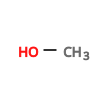

In [60]:
mol

In [61]:
print(mol.write('cif'))

# CIF file generated by openbabel 2.4.1, see http://openbabel.sf.net
data_I
_chemical_name_common ''
loop_
    _atom_site_label
    _atom_site_type_symbol
    _atom_site_fract_x
    _atom_site_fract_y
    _atom_site_fract_z
    _atom_site_occupancy
    C0      C    0.00000   0.00000   0.00000   1.000
    O1      O    0.00000   0.00000   0.00000   1.000



In [62]:
mol.addh()

In [63]:
print(mol.write('cif'))

# CIF file generated by openbabel 2.4.1, see http://openbabel.sf.net
data_I
_chemical_name_common ''
loop_
    _atom_site_label
    _atom_site_type_symbol
    _atom_site_fract_x
    _atom_site_fract_y
    _atom_site_fract_z
    _atom_site_occupancy
    C0      C    0.00000   0.00000   0.00000   1.000
    O1      O    0.00000   0.00000   0.00000   1.000
    H2      H    0.00000   0.00000   0.00000   1.000
    H3      H    0.00000   0.00000   0.00000   1.000
    H4      H    0.00000   0.00000   0.00000   1.000
    H5      H    0.00000   0.00000   0.00000   1.000



In [64]:
mol.make3D()

In [67]:
print(mol.write('cif'))

# CIF file generated by openbabel 2.4.1, see http://openbabel.sf.net
data_I
_chemical_name_common ''
loop_
    _atom_site_label
    _atom_site_type_symbol
    _atom_site_fract_x
    _atom_site_fract_y
    _atom_site_fract_z
    _atom_site_occupancy
    C0      C    1.06562   0.03670  -0.05033   1.000
    O1      O    0.58992  -0.47688   1.18022   1.000
    H2      H    0.69993   1.05877  -0.17388   1.000
    H3      H    0.69597  -0.58198  -0.87175   1.000
    H4      H    2.15837   0.04102  -0.04641   1.000
    H5      H    0.93023  -1.38407   1.26202   1.000



In [69]:
mol.write('cif', 'methanol.cif')

In [70]:
read('methanol.cif')

RuntimeError: Structure has fractional coordinates but not lattice parameters

<span style=color:red>
    FEEDBACK: not sure if above failure (i.e. fractional coordinates without specification of unit cell) is due to mistake by openbabel or what can be expected
</font>

In [100]:
mol = read('286524.cif')  # downloaded a cif file instead

/Users/thomasholmrod/miniconda3/envs/Rietveld/lib/python3.7/site-packages/ase/io/cif.py:372: UserWarning: crystal system 'orthorhombic' is not interpreted for space group Spacegroup(19, setting=1). This may result in wrong setting!
  setting_name, spacegroup))


In [76]:
mol.__class__

list

In [77]:
for atom in mol: print(atom)

O Atom  charge: 0.0 e  position: [1.04741126 1.49087125 8.41073351] Ang
H Atom  charge: 0.0 e  position: [1.74444626 1.3415377  8.85497385] Ang
H Atom  charge: 0.0 e  position: [1.17798915 2.7234891  7.72855247] Ang
H Atom  charge: 0.0 e  position: [1.27975626 3.44847145 8.3803581 ] Ang
H Atom  charge: 0.0 e  position: [0.37779297 2.88267965 7.18523044] Ang
C Atom  charge: 0.0 e  position: [1.96656808 2.69342525 7.14726118] Ang


In [78]:
print(mol)

[<Atom
 {name: 'O',
  ID: 7,
  element: 'O',
  position: UnitNDArray([1.04741126, 1.49087125, 8.41073351]) Ang,
  velocity: UnitNDArray([0., 0., 0.]) Ang / fs}>, <Atom
 {name: 'H',
  ID: 8,
  element: 'H',
  position: UnitNDArray([1.74444626, 1.3415377 , 8.85497385]) Ang,
  velocity: UnitNDArray([0., 0., 0.]) Ang / fs}>, <Atom
 {name: 'H',
  ID: 9,
  element: 'H',
  position: UnitNDArray([1.17798915, 2.7234891 , 7.72855247]) Ang,
  velocity: UnitNDArray([0., 0., 0.]) Ang / fs}>, <Atom
 {name: 'H',
  ID: 10,
  element: 'H',
  position: UnitNDArray([1.27975626, 3.44847145, 8.3803581 ]) Ang,
  velocity: UnitNDArray([0., 0., 0.]) Ang / fs}>, <Atom
 {name: 'H',
  ID: 11,
  element: 'H',
  position: UnitNDArray([0.37779297, 2.88267965, 7.18523044]) Ang,
  velocity: UnitNDArray([0., 0., 0.]) Ang / fs}>, <Atom
 {name: 'C',
  ID: 12,
  element: 'C',
  position: UnitNDArray([1.96656808, 2.69342525, 7.14726118]) Ang,
  velocity: UnitNDArray([0., 0., 0.]) Ang / fs}>]


In [79]:
universe

In [80]:
from MDMC.MD.structures import Molecule

In [81]:
methanol = Molecule(mol)

KeyError: 'atoms'

In [82]:
Molecule?

In [83]:
help(Molecule)

Help on class Molecule in module MDMC.MD.structures:

class Molecule(CompositeStructure)
 |  Molecule(position=None, velocity=(0, 0, 0), name=None, **settings)
 |  
 |  Two or more bonded atoms, passed either as individual atoms or as groups
 |  
 |  Must be declared with at least 2 atoms.
 |  
 |  Parameters
 |  ----------
 |  position : list, tuple, NumPy array, optional
 |      A 3 element list, tuple or array with the position in units of Ang. The
 |      default is None, which sets the position of the Molecule to be equal to
 |      the center of mass of the atoms in the Molecule.
 |  velocity : list, tuple, NumPy array, optional
 |      A 3 element list, tuple or array with the velocity in units of Ang. The
 |      default is (0., 0., 0.).
 |  name : str, optional
 |      The name of the structure. The default is None.
 |  **settings
 |      interactions : list
 |          A list of Interactions acting on atoms within the Molecule. The
 |          interactions keyword provides a 

In [84]:
methanol = Molecule(atoms=mol)

<span style=color:red>
    FEEDBACK: There is a mismatch between online help and documentation (keyword `atoms` is not documented in the online help)
</font>

In [87]:
from MDMC.gui import view
view(methanol)

AttributeError: 'Viewer' object has no attribute 'copy_image'

<span style=color:red>
    FEEDBACK: Some kind of bug. Am I using the right version?)
</font>

In [88]:
import sys
sys.version

'3.7.5 (default, Oct 25 2019, 10:52:18) \n[Clang 4.0.1 (tags/RELEASE_401/final)]'

In [89]:
!git status

On branch master
Your branch is up to date with 'origin/master'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git checkout -- <file>..." to discard changes in working directory)

	modified:   .DS_Store

Untracked files:
  (use "git add <file>..." to include in what will be committed)

	#395 full user testing.ipynb
	.ipynb_checkpoints/
	286524.cif
	MDMC.egg-info/
	MDMC/.ipynb_checkpoints/
	MDMC/Untitled1.ipynb
	MDMC/kde.vs.hist.png
	Untitled.ipynb
	Untitled1.ipynb
	build/
	dist/
	methanol.cif

no changes added to commit (use "git add" and/or "git commit -a")


In [90]:
methanol.interactions

[<BondAngle
  {function: None,
   constrained: False}>, <BondAngle
  {function: None,
   constrained: False}>, <Bond
  {function: None,
   constrained: False}>, <BondAngle
  {function: None,
   constrained: False}>, <BondAngle
  {function: None,
   constrained: False}>, <Bond
  {function: None,
   constrained: False}>, <BondAngle
  {function: None,
   constrained: False}>, <Bond
  {function: None,
   constrained: False}>, <Bond
  {function: None,
   constrained: False}>, <BondAngle
  {function: None,
   constrained: False}>, <BondAngle
  {function: None,
   constrained: False}>, <Bond
  {function: None,
   constrained: False}>, <Coulombic
  {function: <Coulomb
  {parameters: array([<Parameter
  {name: 'charge',
   value: 0.0 e,
   unit: 'e',
   fixed: False,
   constraints: None,
   interactions_name: None,
   functions_name: None,
   tied: False}>], dtype=object)}>,
   atom_types: [],
   cutoff: 10.0 Ang}>, <Coulombic
  {function: <Coulomb
  {parameters: array([<Parameter
  {name: 'ch

In [91]:
print(methanol.interactions)

[<BondAngle
 {function: None,
  constrained: False}>, <BondAngle
 {function: None,
  constrained: False}>, <Bond
 {function: None,
  constrained: False}>, <BondAngle
 {function: None,
  constrained: False}>, <BondAngle
 {function: None,
  constrained: False}>, <Bond
 {function: None,
  constrained: False}>, <BondAngle
 {function: None,
  constrained: False}>, <Bond
 {function: None,
  constrained: False}>, <Bond
 {function: None,
  constrained: False}>, <BondAngle
 {function: None,
  constrained: False}>, <BondAngle
 {function: None,
  constrained: False}>, <Bond
 {function: None,
  constrained: False}>, <Coulombic
 {function: <Coulomb
 {parameters: array([<Parameter
 {name: 'charge',
  value: 0.0 e,
  unit: 'e',
  fixed: False,
  constraints: None,
  interactions_name: None,
  functions_name: None,
  tied: False}>], dtype=object)}>,
  atom_types: [],
  cutoff: 10.0 Ang}>, <Coulombic
 {function: <Coulomb
 {parameters: array([<Parameter
 {name: 'charge',
  value: 0.0 e,
  unit: 'e',
  f

<span style=color:red>
    FEEDBACK: A nice representation of the interactions would be really useful. Even better if one could also be selective, e.g. `print(methanol.interactions, type='bonds')`
</font>

In [95]:
bond = methanol.interactions[0]

In [96]:
help(bond)

Help on BondAngle in module MDMC.MD.structures object:

class BondAngle(Constrainable, BondedInteraction)
 |  BondAngle(*atom_tuples, **settings)
 |  
 |  A bond angle between any two bonds
 |  
 |  Requires three atoms (rotation around central atom) in each atom_tuple. The
 |  atoms are ordered i, j, k, where j is the central atom.
 |  
 |  So BondAngle(i, j, k) == BondAngle(k, j, i)
 |  
 |  Parameters
 |  ----------
 |  atom_tuples : list
 |      A list of tuples. Each tuples contains Atoms which are bonded together.
 |      For three or more Atoms the order of the Atoms within each tuple is
 |      important.
 |  **settings
 |  
 |  Method resolution order:
 |      BondAngle
 |      Constrainable
 |      BondedInteraction
 |      Interaction
 |      abc.ABC
 |      builtins.object
 |  
 |  Methods defined here:
 |  
 |  __init__(self, *atom_tuples, **settings)
 |      Arguments:
 |      atom_tuples - One or more tuples consisting of one or more Atom objects.
 |      Each tuple cont

In [99]:
bond.element_list(), bond.element_tuple()

(['H', 'H', 'H'], ('H', 'H', 'H'))

<span style=color:red>
    FEEDBACK: 1. Maybe a bit overkill. Why not just `bond.elements`?
</font>


<span style=color:red>
    FEEDBACK: 2. Is `element` the right term? and shouldn't this be atom types or indexes?
</font>



<span style=color:red>
    FEEDBACK: 3. I would expect either 'bond.element_list` (i.e. attribute) or `bond.get_element_list()` (i.e. method). Some programs provide both versions (using the `getter` and `setter` decorations I guess)
</font>

Are the atoms in the cif file numbered?

In [103]:
txt = open('286524.cif').read()

In [104]:
print(txt)

####################################################################### 
# 
# This file contains crystal structure data downloaded from the 
# Cambridge Structural Database (CSD) hosted by the Cambridge 
# Crystallographic Data Centre (CCDC).
# 
# Full information about CCDC data access policies and citation 
# guidelines are available at http://www.ccdc.cam.ac.uk/access/V1 
# 
# Audit and citation data items may have been added by the CCDC. 
# Please retain this information to preserve the provenance of 
# this file and to allow appropriate attribution of the data. 
# 
#######################################################################

data_1
_audit_block_doi                 10.5517/cc9m4qr
_database_code_depnum_ccdc_archive 'CCDC 286524'
loop_
_citation_id
_citation_doi
_citation_year
1 10.1021/cg0701877 2008
_audit_update_record             
;
2005-10-12 deposited with the CCDC.	2020-03-29 downloaded from the CCDC.
;

_audit_creation_method           SHELXL-97

_chemical_name_s

CIF file contains unique atom names. How do I those in identifiers and methanol?

In [108]:
mol

[<Atom
  {name: 'O',
   ID: 14,
   element: 'O',
   position: UnitNDArray([1.04741126, 1.49087125, 8.41073351]) Ang,
   velocity: UnitNDArray([0., 0., 0.]) Ang / fs}>, <Atom
  {name: 'H',
   ID: 15,
   element: 'H',
   position: UnitNDArray([1.74444626, 1.3415377 , 8.85497385]) Ang,
   velocity: UnitNDArray([0., 0., 0.]) Ang / fs}>, <Atom
  {name: 'H',
   ID: 16,
   element: 'H',
   position: UnitNDArray([1.17798915, 2.7234891 , 7.72855247]) Ang,
   velocity: UnitNDArray([0., 0., 0.]) Ang / fs}>, <Atom
  {name: 'H',
   ID: 17,
   element: 'H',
   position: UnitNDArray([1.27975626, 3.44847145, 8.3803581 ]) Ang,
   velocity: UnitNDArray([0., 0., 0.]) Ang / fs}>, <Atom
  {name: 'H',
   ID: 18,
   element: 'H',
   position: UnitNDArray([0.37779297, 2.88267965, 7.18523044]) Ang,
   velocity: UnitNDArray([0., 0., 0.]) Ang / fs}>, <Atom
  {name: 'C',
   ID: 19,
   element: 'C',
   position: UnitNDArray([1.96656808, 2.69342525, 7.14726118]) Ang,
   velocity: UnitNDArray([0., 0., 0.]) Ang / fs}

Does not look like atom names is carried over!

<span style=color:red>
    FEEDBACK: atom names should be carried over from cif file
</font>

<span style=color:red>
    FEEDBACK: Is there a risk that users input coordinates in a unit different from `Ang` and then they would be (wrongly) shown with the unit `Ang`?
</font>